# Semantic Search

In [ ]:
!pip install faiss-cpu sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 83.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Library Imports

In [ ]:
import pandas as pd
import numpy as np
import pickle
import faiss
import os
import time
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer, CrossEncoder, util
from tqdm.auto import tqdm

sns.set_theme(style='whitegrid', palette='pastel')
plt.rcParams['figure.figsize'] = (12, 5)

print('All imports successful.')

All imports successful.


## 3. Load Pre-computed Embeddings
Load the product DataFrames and Dense Embeddings into memory for each model.

In [ ]:
base_path = "/content/drive/MyDrive/Data Science Project II/code"

if not os.path.exists(base_path):
    raise FileNotFoundError(f"Base path not found: {base_path}")

embedding_files = [f for f in os.listdir(base_path)
                   if f.startswith("embeddings_") and f.endswith(".pkl")]

print("Found files:", embedding_files)

if not embedding_files:
    raise ValueError("No embedding files found in the specified directory.")

loaded_models = {}

for file in embedding_files:
    full_path = os.path.join(base_path, file)
    with open(full_path, 'rb') as f:
        data = pickle.load(f)
        loaded_models[data['model_name']] = data

print("Loaded models:", list(loaded_models.keys()))
assert len(loaded_models) > 0, "No models were loaded!"

Found files: ['embeddings_all-MiniLM-L6-v2.pkl', 'embeddings_all-mpnet-base-v2.pkl', 'embeddings_paraphrase-MiniLM-L3-v2.pkl']
Loaded models: ['all-MiniLM-L6-v2', 'all-mpnet-base-v2', 'paraphrase-MiniLM-L3-v2']


## 4. Query Dataset Construction
A diverse set of 100 synthetic queries across five intent types.

In [ ]:
short_queries = [
    "running shoes", "summer dress", "gaming laptop", "wireless earbuds",
    "formal shirt", "denim jeans", "smart watch", "yoga mat",
    "leather wallet", "travel backpack", "office chair", "hair shampoo",
    "face cream", "water bottle", "bluetooth speaker", "winter jacket",
    "sports bra", "kitchen knife", "study table", "mobile charger"
]

In [ ]:
long_queries = [
    "comfortable running shoes for daily jogging",
    "lightweight summer dress for hot weather",
    "high performance gaming laptop for heavy games",
    "wireless earbuds with long battery life",
    "formal shirt suitable for office meetings",
    "slim fit denim jeans for casual wear",
    "smart watch with health tracking features",
    "non slip yoga mat for home workouts",
    "genuine leather wallet with multiple compartments",
    "durable travel backpack for long trips",
    "ergonomic office chair for back support",
    "anti dandruff shampoo for daily use",
    "face cream for glowing and healthy skin",
    "insulated water bottle for keeping drinks cold",
    "portable bluetooth speaker with deep bass",
    "warm winter jacket for extreme cold",
    "comfortable sports bra for gym workouts",
    "sharp kitchen knife for cutting vegetables",
    "wooden study table for students",
    "fast charging mobile charger for smartphones"
]

In [ ]:
attribute_queries = [
    "red floral dress for women",
    "black wireless headphones with mic",
    "waterproof laptop backpack for college",
    "organic herbal shampoo for hair fall",
    "stainless steel water bottle for office",
    "blue denim jeans slim fit",
    "white formal shirt for men",
    "gaming mouse with rgb lighting",
    "lightweight running shoes for men",
    "pink casual top for girls",
    "winter jacket with hood for women",
    "large capacity travel bag",
    "soft cotton t shirt for summer",
    "smart watch with heart rate monitor",
    "non stick frying pan for kitchen",
    "high speed usb charger",
    "portable power bank with fast charging",
    "comfortable office chair with wheels",
    "durable leather belt for men",
    "compact bluetooth speaker"
]

In [ ]:
use_case_queries = [
    "shoes suitable for marathon running",
    "dress for attending a wedding party",
    "laptop for programming and machine learning",
    "earbuds for online meetings and calls",
    "shirt for business formal events",
    "jeans for casual daily wear",
    "watch for fitness tracking and workouts",
    "mat for yoga and meditation",
    "wallet for carrying multiple cards",
    "bag for weekend travel",
    "chair for long working hours",
    "shampoo for dry and damaged hair",
    "cream for reducing acne and pimples",
    "bottle for gym and workouts",
    "speaker for outdoor parties",
    "jacket for snowy weather",
    "sports bra for high impact training",
    "knife for professional cooking",
    "table for studying and writing",
    "charger for fast charging android phones"
]

In [ ]:
semantic_queries = [
    "footwear for jogging comfortably",
    "outfit suitable for summer season",
    "powerful laptop for gaming purposes",
    "cordless earphones with good battery backup",
    "office wear shirt for professionals",
    "casual jeans with modern fit",
    "fitness tracker watch with smart features",
    "exercise mat with anti slip surface",
    "premium wallet made of leather",
    "backpack for traveling long distances",
    "comfortable chair for office work",
    "hair cleanser for dandruff control",
    "skin care cream for glowing face",
    "bottle that keeps water cold for hours",
    "speaker with strong bass and portability",
    "jacket to keep warm in winter",
    "gym bra for intense workouts",
    "kitchen tool for chopping vegetables",
    "desk for student study setup",
    "phone charger with quick charge support"
]

In [ ]:
all_queries = (
    short_queries +
    long_queries +
    attribute_queries +
    use_case_queries +
    semantic_queries
)
print("Total Queries:", len(all_queries))  # Should be 100

Total Queries: 100


## 5. Build FAISS Semantic Indices
Pure dense indexing — **no BM25 or keyword index**.
Two precision modes:
- **`IndexFlatIP`** (≤100 K items): exact cosine search, highest accuracy.
- **`IndexHNSWFlat`** (>100 K items): approximate graph search, near-lossless accuracy at a fraction of the cost.

In [ ]:
index_store = {}
sample_df   = list(loaded_models.values())[0]['df']

assert 'product_text' in sample_df.columns, "Column 'product_text' not found!"
assert 'uniq_id'       in sample_df.columns, "Column 'uniq_id' not found!"

for model_name, data in loaded_models.items():
    print(f'Building FAISS index for: {model_name}')
    embeddings = np.array(data['embeddings']).astype('float32')
    faiss.normalize_L2(embeddings)        # unit-length → dot product = cosine similarity

    dim, n = embeddings.shape[1], embeddings.shape[0]

    if n > 100_000:
        print(f"  Large corpus ({n} items) — using IndexHNSWFlat.")
        index = faiss.IndexHNSWFlat(dim, 32)
        index.hnsw.efConstruction = 200   # higher → better graph quality at build time
        index.hnsw.efSearch       = 128   # higher → better recall at query time
    else:
        index = faiss.IndexFlatIP(dim)    # exact search for smaller corpora

    index.add(embeddings)

    index_store[model_name] = {
        'index': index,
        'df':    data['df'].reset_index(drop=True),
        'model': SentenceTransformer(model_name),
    }
    print(f"  Done — {n} vectors, dim={dim}")

print("\nAll FAISS indices built.")

Building FAISS index for: all-MiniLM-L6-v2


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  Done — 19995 vectors, dim=384

All FAISS indices built.


## 6. Ground Truth Generation (Cross-Encoder)
A Cross-Encoder (`ms-marco-MiniLM-L-6-v2`) provides unbiased relevance labels.
It is **too slow for real-time retrieval** but makes a perfect accuracy "teacher" for evaluating our faster bi-encoders.

**Change from the original:** Stage-1 candidate retrieval now uses **pure dense search** (no BM25 mix) so the ground truth is not tainted by keyword signals.

In [ ]:
cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')
print("Cross-encoder loaded.")

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Cross-encoder loaded.


In [ ]:
def build_ground_truth_cross_encoder(
    df, queries, index_store,
    cross_encoder, candidate_k=100, final_k=50
):
    """
    Two-stage ground truth construction — fully keyword-free.

    Stage 1 — Dense bi-encoder retrieves `candidate_k` candidates (fast).
    Stage 2 — Cross-encoder re-scores candidates for accurate relevance labels.

    Using a *different* model for Stage 1 vs. evaluation prevents leakage.
    """
    ground_truth = {}

    bi_model_name = list(index_store.keys())[0]
    bi_model      = index_store[bi_model_name]['model']
    bi_index      = index_store[bi_model_name]['index']

    candidate_k = min(candidate_k, len(df))
    final_k     = min(final_k,     len(df))

    for query in tqdm(queries, desc="Building Ground Truth"):

        # Stage 1: pure semantic retrieval
        q_emb = bi_model.encode([query], normalize_embeddings=True).astype('float32')
        D, I  = bi_index.search(q_emb, candidate_k)

        candidate_indices = I[0]

        # Stage 2: cross-encoder re-scoring
        candidate_texts = [df.iloc[i]['product_text'] for i in candidate_indices]
        pairs     = [[query, t] for t in candidate_texts]
        ce_scores = cross_encoder.predict(pairs)

        # Softmax-normalise → [0, 1] relevance weights
        ce_exp  = np.exp(ce_scores - ce_scores.max())
        ce_norm = ce_exp / ce_exp.sum()

        top_local = np.argsort(ce_norm)[-final_k:][::-1]

        ground_truth[query] = {
            str(df.iloc[candidate_indices[li]]['uniq_id']): float(ce_norm[li])
            for li in top_local
            if ce_norm[li] > 0
        }

    return ground_truth

In [ ]:
ground_truth = build_ground_truth_cross_encoder(
    sample_df,
    all_queries,
    index_store,
    cross_encoder,
    candidate_k=100,
    final_k=50
)
print("Ground truth construction complete.")

Building Ground Truth:   0%|          | 0/100 [00:00<?, ?it/s]

Ground truth construction complete.


In [ ]:
def dense_search(query, bi_model, faiss_index, df, top_k):
    """
    Pure semantic retrieval.
    Encodes the query with the same bi-encoder used to build the index,
    normalises to unit length, then runs a cosine-similarity FAISS search.
    No keyword signals involved.
    """
    q_emb = bi_model.encode([query], normalize_embeddings=True).astype('float32')
    D, I  = faiss_index.search(q_emb, top_k)
    return [str(df.iloc[i]['uniq_id']) for i in I[0]]

In [ ]:
def ndcg_at_k(retrieved_ids, relevance_dict, k):
    dcg  = sum(relevance_dict.get(pid, 0.0) / np.log2(i + 2)
               for i, pid in enumerate(retrieved_ids[:k]))
    idcg = sum(rel / np.log2(i + 2)
               for i, rel in enumerate(sorted(relevance_dict.values(), reverse=True)[:k]))
    return dcg / idcg if idcg > 0 else 0.0

## 7. Model Evaluation Pipeline
Evaluates every bi-encoder model with **pure semantic retrieval** across:
- **MRR** — Mean Reciprocal Rank (first relevant hit position)
- **Precision@K** — fraction of top-K that are relevant
- **Recall@K** — fraction of relevant items recovered in top-K
- **NDCG@K** — quality-weighted ranking score
- **Latency** — mean and P95 query time (ms)

In [ ]:
def evaluate_models(index_store, ground_truth, top_k_values=[5, 10, 20]):
    """
    Evaluates all bi-encoder models using pure dense (semantic) retrieval.
    BM25 / keyword weighting is not used at any stage.
    """
    results_all_k = {}

    for top_k in top_k_values:
        all_metrics = {}

        for model_name, data in index_store.items():
            mrr_list, prec_list, recall_list, ndcg_list, latency_list =                 [], [], [], [], []

            for query, rel_dict in ground_truth.items():

                t0 = time.perf_counter()
                retrieved_ids = dense_search(
                    query, data['model'], data['index'], data['df'], top_k
                )
                latency_list.append((time.perf_counter() - t0) * 1000)

                relevant_ids = set(rel_dict.keys())
                hits = sum(pid in relevant_ids for pid in retrieved_ids)

                prec_list.append(hits / top_k)
                recall_list.append(hits / len(relevant_ids) if relevant_ids else 0)

                rank = next(
                    (i + 1 for i, pid in enumerate(retrieved_ids) if pid in relevant_ids),
                    0
                )
                mrr_list.append(1 / rank if rank > 0 else 0)
                ndcg_list.append(ndcg_at_k(retrieved_ids, rel_dict, top_k))

            all_metrics[model_name] = {
                "MRR":                    round(np.mean(mrr_list), 4),
                f"Precision@{top_k}":     round(np.mean(prec_list), 4),
                f"Recall@{top_k}":        round(np.mean(recall_list), 4),
                f"NDCG@{top_k}":          round(np.mean(ndcg_list), 4),
                "Latency_ms (mean)":      round(np.mean(latency_list), 2),
                "Latency_ms (p95)":       round(np.percentile(latency_list, 95), 2),
            }

        results_all_k[top_k] = pd.DataFrame(all_metrics).T

    return results_all_k

## 8. Run Evaluation

In [ ]:
results = evaluate_models(
    index_store,
    ground_truth,
    top_k_values=[5, 10, 20, 30]
)

for k, df_result in results.items():
    print(f"\n===== RESULTS @ TOP-{k} =====")
    display(df_result)


===== RESULTS @ TOP-5 =====


,MRR,Precision@5,Recall@5,NDCG@5,Latency_ms (mean),Latency_ms (p95)
all-MiniLM-L6-v2,0.9620,0.910,0.0910,0.3880,8.80,11.12
all-mpnet-base-v2,0.9053,0.772,0.0772,0.3569,18.55,21.92
paraphrase-MiniLM-L3-v2,0.8557,0.678,0.0678,0.3489,5.82,6.31



===== RESULTS @ TOP-10 =====


,MRR,Precision@10,Recall@10,NDCG@10,Latency_ms (mean),Latency_ms (p95)
all-MiniLM-L6-v2,0.9647,0.886,0.1772,0.4248,8.46,9.62
all-mpnet-base-v2,0.9087,0.727,0.1454,0.3963,16.91,20.02
paraphrase-MiniLM-L3-v2,0.8568,0.603,0.1206,0.3806,6.41,7.45



===== RESULTS @ TOP-20 =====


,MRR,Precision@20,Recall@20,NDCG@20,Latency_ms (mean),Latency_ms (p95)
all-MiniLM-L6-v2,0.9647,0.8375,0.3350,0.4773,9.29,10.93
all-mpnet-base-v2,0.9094,0.6585,0.2634,0.4373,17.64,20.90
paraphrase-MiniLM-L3-v2,0.8595,0.5235,0.2094,0.4236,9.47,12.26



===== RESULTS @ TOP-30 =====


,MRR,Precision@30,Recall@30,NDCG@30,Latency_ms (mean),Latency_ms (p95)
all-MiniLM-L6-v2,0.9647,0.7833,0.4700,0.5182,13.21,15.95
all-mpnet-base-v2,0.9094,0.6073,0.3644,0.4689,23.10,30.43
paraphrase-MiniLM-L3-v2,0.8595,0.4623,0.2774,0.4509,7.24,8.16


## 9. Best Model Selection
Rank models by a **composite score** (MRR + Precision@10 + NDCG@10).
All three metrics reflect pure semantic quality — no keyword component.

Best model : all-MiniLM-L6-v2
  Composite  = 2.2755
  MRR        = 0.9647
  Precision@10 = 0.8860
  NDCG@10 = 0.4248
  Latency(mean) = 8.46 ms
  Latency(p95)  = 9.62 ms


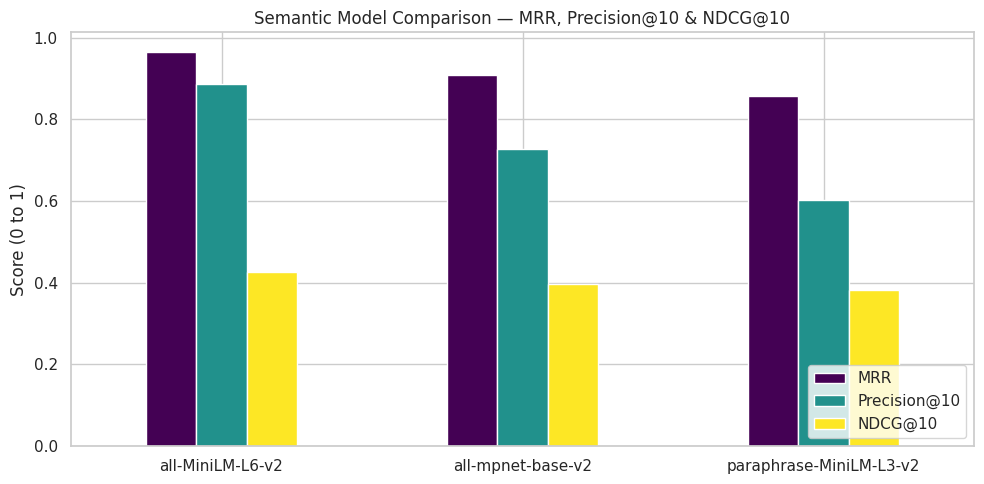

In [ ]:
eval_k   = 10
ndcg_col = f"NDCG@{eval_k}"
prec_col = f"Precision@{eval_k}"
results_df = results[eval_k].copy()

results_df['Composite_Score'] = (
    results_df['MRR'] +
    results_df[prec_col] +
    results_df[ndcg_col]
)

best_model_name = results_df['Composite_Score'].idxmax()

print(f"Best model : {best_model_name}")
print(f"  Composite  = {results_df.loc[best_model_name, 'Composite_Score']:.4f}")
print(f"  MRR        = {results_df.loc[best_model_name, 'MRR']:.4f}")
print(f"  {prec_col} = {results_df.loc[best_model_name, prec_col]:.4f}")
print(f"  {ndcg_col} = {results_df.loc[best_model_name, ndcg_col]:.4f}")
print(f"  Latency(mean) = {results_df.loc[best_model_name, 'Latency_ms (mean)']:.2f} ms")
print(f"  Latency(p95)  = {results_df.loc[best_model_name, 'Latency_ms (p95)']:.2f} ms")

plot_cols = ['MRR', prec_col, ndcg_col]
results_df[plot_cols].plot(kind='bar', figsize=(10, 5), rot=0, colormap='viridis')
plt.title(f"Semantic Model Comparison — MRR, {prec_col} & {ndcg_col}")
plt.ylabel("Score (0 to 1)")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 10. Export Artifacts for Streamlit Deployment
Save the winning model's FAISS index and product DataFrame.
BM25 corpus and `best_alpha` are **not saved** — they are no longer needed.

In [ ]:
best_data  = index_store[best_model_name]
best_index = best_data['index']
best_df    = best_data['df']

save_dir = "/content/drive/MyDrive/Data Science Project II/project_try"
os.makedirs(save_dir, exist_ok=True)

# 1. FAISS index
faiss_path = os.path.join(save_dir, "best_model.index")
faiss.write_index(best_index, faiss_path)
print(f" FAISS index  → {faiss_path}")

# 2. Product DataFrame
df_path = os.path.join(save_dir, "products.pkl")
best_df.to_pickle(df_path)
print(f" DataFrame    → {df_path}")

# 3. Metadata
meta = {
    "model_name": best_model_name,
    "ndcg_score":  float(results_df.loc[best_model_name, ndcg_col]),
    "eval_k":      eval_k,
    "search_mode": "pure_semantic"   # no keyword component
}
meta_path = os.path.join(save_dir, "meta.json")
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)
print(f" Metadata     → {meta_path}")

print("\n All files saved. Ready to build the Streamlit UI.")

print(f"\nFiles in {save_dir}:")
for fname in sorted(os.listdir(save_dir)):
    size_kb = os.path.getsize(os.path.join(save_dir, fname)) / 1024
    print(f"   {fname:35s}  {size_kb:,.0f} KB")

 FAISS index  → /content/drive/MyDrive/Data Science Project II/project_try/best_model.index
 DataFrame    → /content/drive/MyDrive/Data Science Project II/project_try/products.pkl
 Metadata     → /content/drive/MyDrive/Data Science Project II/project_try/meta.json

 All files saved. Ready to build the Streamlit UI.

Files in /content/drive/MyDrive/Data Science Project II/project_try:
   best_model.index                     29,993 KB
   meta.json                            0 KB
   products.pkl                         26,353 KB
